# UK Biobank — Authorship Analysis

Analysis of the authorship of 20 years of UK Biobank publications.

**Sections**
1. **Setup** — imports, environment, shared formatting dictionary
2. **Data cleaning** — build a tidy *author–paper* long table (one author–paper pair per row)
3. **Geographic distribution** — world map of where authors are based (raw + normalised)
4. **Top institutes** — bar chart of the most prolific institutions
5. **Gender trends over time** — share of authorships by inferred gender
6. **Network collaboration** — final-snapshot co-authorship network

> **Modularisation note.** Functions are written here in the notebook while the
> analysis is still being developed. They are deliberately kept *pure* (they take
> data + the shared `STYLE` dict and return objects / figures) so that, as a final
> step, they can be lifted verbatim into `src/utils/author_utils.py` — mirroring the
> `utils/patent_utils.py` pattern used by `01_analysis_01_patents_analysis_modularized.ipynb`.

## 1. Setup

Imports, working directory, and the **single shared formatting dictionary** (`STYLE`)
that every visualisation in this notebook reads from — colour palette, figure sizes,
font sizes, dpi, colormap.

In [1]:
import os
import sys
import ast
from functools import lru_cache
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import geopandas as gpd
import networkx as nx
from scipy import sparse as sp
import gender_guesser.detector as gender_detector
import nomquamgender as nqg          # larger offline name-gender model (2nd-pass refine)

import warnings
warnings.filterwarnings("ignore")

# Run from the project root so that relative paths ('data/...', 'fig/...') resolve,
# regardless of how many times this cell is run.
ROOT = Path.cwd()
if ROOT.name == "src":
    os.chdir(ROOT.parent)
ROOT = Path.cwd()
print("Working directory:", ROOT)

# Make sure the `src` package dir is importable, then reuse the patent
# country-cleaning helpers (ISO matching already implemented there).
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from utils import patent_utils as patent

Working directory: /Users/valler/Python/RA/20_years_of_ukb


In [2]:
# =============================================================================
# SHARED FORMATTING DICTIONARY  -- every figure reads from this
# =============================================================================
STYLE = {
    # four customised colours (same palette used across the project)
    "colors": ["#B80C09", "#D4AF37", "#6E8B3D", "#345995"],

    # figure sizes
    "figsize": (12, 7),
    "figsize_wide": (14, 7),
    "figsize_map": (14, 8),
    "figsize_network": (12, 12),

    # font sizes
    "title_fs": 16,
    "label_fs": 13,
    "tick_fs": 11,
    "annot_fs": 10,
    "legend_fs": 11,

    # misc
    "dpi": 300,
    "cmap": "ocean",
    "edgecolor": "grey",
    "save": False,            # set True to write figures to fig/authors/
    "savedir": "fig/authors",
}

# semantic colour roles drawn from the 4-colour palette
STYLE["c_primary"]   = STYLE["colors"][3]   # blue
STYLE["c_accent"]    = STYLE["colors"][0]   # red
STYLE["c_gold"]      = STYLE["colors"][1]   # gold
STYLE["c_green"]     = STYLE["colors"][2]   # green
STYLE["gender_colors"] = {"female": STYLE["colors"][0], "male": STYLE["colors"][3],
                          "unknown": "#BBBBBB"}


def apply_style(style=STYLE):
    """Push the shared style into matplotlib rcParams (call once / after edits)."""
    plt.rcParams.update({
        "figure.dpi": 110,            # on-screen
        "savefig.dpi": style["dpi"],  # exported
        "axes.titlesize": style["title_fs"],
        "axes.labelsize": style["label_fs"],
        "xtick.labelsize": style["tick_fs"],
        "ytick.labelsize": style["tick_fs"],
        "legend.fontsize": style["legend_fs"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "DejaVu Sans",
    })
    sns.set_palette(style["colors"])


def extended_palette(n, style=STYLE):
    """N colours interpolated across the 4 brand colours (for >4 categories)."""
    from matplotlib.colors import LinearSegmentedColormap
    if n <= len(style["colors"]):
        return style["colors"][:n]
    cmap = LinearSegmentedColormap.from_list("brand", style["colors"], N=256)
    return [cmap(i / (n - 1)) for i in range(n)]


def savefig(fig, name, style=STYLE):
    """Optionally persist a figure to the configured directory."""
    if style.get("save"):
        outdir = Path(style["savedir"]); outdir.mkdir(parents=True, exist_ok=True)
        fig.savefig(outdir / f"{name}.pdf", dpi=style["dpi"], bbox_inches="tight")
        print("saved ->", outdir / f"{name}.pdf")


apply_style()
print("Palette:", STYLE["colors"])

Palette: ['#B80C09', '#D4AF37', '#6E8B3D', '#345995']


## 2. Data cleaning — the author–paper long table

We depart from the raw paper-level `df_dimensions.xlsx` and build a tidy
**`df_ap`** table where **each row is one (author, paper) pair**.

An author can appear on many papers,
and we need the per-paper context for *every* downstream analysis:

* geography & institutes → an author's affiliation can differ per paper,
* gender trends → we need the *year* of each authorship,
* network → co-authorship edges are defined *within* a paper.

A one-row-per-author table would throw away exactly this paper context (and the
network could not be rebuilt from it). The long table does not "explode": it has
~10<sup>5</sup> rows (≈ the total number of author slots), which is small. We derive
the per-author summary (`df_authors`) from it by grouping when needed.

The richest source is the `authors` column — each entry carries the author's
`researcher_id`, name, and **per-paper affiliation** (institution name, grid id,
country, country code). We parse that into `df_ap`.

In [5]:
def parse_listcol(x):
    """Safely parse a stringified list-of-dicts cell into a Python list."""
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            return v if isinstance(v, list) else []
        except Exception:
            return []
    return []


def _norm_name_id(first, last):
    """Synthetic stable id for authors that are missing a researcher_id."""
    f = (first or "").strip().lower()
    l = (last or "").strip().lower()
    return f"name::{f}|{l}" if (f or l) else None


def pick_main_affiliation(author):
    """Choose ONE 'main' affiliation for an author on a paper, and say how.

    Definition (because 38% of author slots list >=2 affiliations, max 26):
    the author's **main institutional home** = the listed affiliation whose grid id
    equals their `current_organization_id` (the principal org Dimensions records for
    them). If that org is absent from this paper's list (or the author has no
    current org), we fall back to the **first-listed** affiliation. Returns
    (affiliation_dict, source) where source ∈ {'current_org','first_listed','none'}.
    """
    affs = author.get("affiliations") or []
    if not affs:
        return {}, "none"
    cur = author.get("current_organization_id")
    if cur:
        for af in affs:
            if isinstance(af, dict) and af.get("id") == cur:
                return af, "current_org"
    return (affs[0] if isinstance(affs[0], dict) else {}), "first_listed"


def build_author_paper_table(df):
    """Explode the `authors` column into one row per (author, paper).

    Returns a long DataFrame with author identity, the paper context (id, year,
    citations) and the *primary* (first) affiliation for that author on that paper.
    """
    rows = []
    for _, r in df.iterrows():
        paper_id = r["id"]
        year = r["year"]
        cited = r.get("times_cited", np.nan)
        for a in parse_listcol(r["authors"]):
            if not isinstance(a, dict):
                continue
            rid = a.get("researcher_id") or _norm_name_id(a.get("first_name"), a.get("last_name"))
            if rid is None:
                continue  # cannot identify this author at all
            aff, aff_source = pick_main_affiliation(a)   # main home, see definition
            rows.append({
                "paper_id": paper_id,
                "year": year,
                "times_cited": cited,
                "author_id": rid,
                "first_name": (a.get("first_name") or "").strip(),
                "last_name": (a.get("last_name") or "").strip(),
                "is_corresponding": bool(a.get("corresponding")),
                "n_affiliations": len(a.get("affiliations") or []),
                "current_org_id": a.get("current_organization_id"),
                "org_name": aff.get("name"),
                "org_grid": aff.get("id"),
                "country": aff.get("country"),
                "country_code": aff.get("country_code"),
                "aff_source": aff_source,   # 'current_org' | 'first_listed' | 'none'
            })
    ap = pd.DataFrame(rows)
    ap["full_name"] = (ap["first_name"] + " " + ap["last_name"]).str.strip()
    # one author can legitimately list the same paper twice (multi-affiliation) ->
    # keep a single (author, paper) row for counting purposes.
    ap = ap.drop_duplicates(subset=["author_id", "paper_id"]).reset_index(drop=True)
    ap["year"] = pd.to_numeric(ap["year"], errors="coerce")
    ap["times_cited"] = pd.to_numeric(ap["times_cited"], errors="coerce").fillna(0)
    return ap


# ---- FOR (Fields of Research, 2020 ANZSRC) -----------------------------------
# Each category_for_2020 entry is {'id', 'name'} where name starts with a numeric
# code: 2-digit = L2 division (e.g. '32 Biomedical and Clinical Sciences'),
# 4-digit = L4 field (e.g. '3212 Ophthalmology and Optometry').
def _split_for_name(name):
    """Return (code, label, level) from a FOR name string, or (None, None, None)."""
    if not isinstance(name, str) or not name.strip():
        return None, None, None
    parts = name.strip().split(" ", 1)
    code = parts[0]
    label = parts[1].strip() if len(parts) > 1 else ""
    if code.isdigit() and len(code) == 2:
        return code, label, "L2"
    if code.isdigit() and len(code) == 4:
        return code, label, "L4"
    return None, None, None


def build_for_lookup(df):
    """Global 2-digit division code -> division label, harvested from the data."""
    lut = {}
    for cats in df["category_for_2020"].apply(parse_listcol):
        for c in cats:
            if isinstance(c, dict):
                code, label, level = _split_for_name(c.get("name"))
                if level == "L2" and code not in lut:
                    lut[code] = label
    return lut


def build_paper_for_table(df, div_lut):
    """One row per paper with its FOR L2/L4 lists and a single primary division.

    `primary_for_l2` is the division of the *first-listed* category (Dimensions
    orders categories by relevance), with the 2-digit prefix of a 4-digit code
    resolved to its division label via `div_lut`. Missing/garbled -> 'Unclassified'.
    """
    rows = []
    for _, r in df.iterrows():
        cats = parse_listcol(r["category_for_2020"])
        l2, l4 = [], []
        primary = None
        for c in cats:
            if not isinstance(c, dict):
                continue
            code, label, level = _split_for_name(c.get("name"))
            if level == "L2":
                l2.append(label)
                if primary is None:
                    primary = label
            elif level == "L4":
                l4.append(label)
                if primary is None:                      # resolve via 2-digit prefix
                    primary = div_lut.get(code[:2])
        rows.append({
            "paper_id": r["id"],
            "for_l2": sorted(set(l2)),
            "for_l4": sorted(set(l4)),
            "primary_for_l2": primary or "Unclassified",
        })
    return pd.DataFrame(rows)

In [6]:
# Load the raw paper-level data.
# Reading the 73 MB .xlsx (~10s) and parsing the nested `authors` column (~10s) are
# the slow steps, so we cache the parsed frame to a pickle keyed on the source file's
# mtime: the first run pays ~20s, later runs reload in ~1s (delete the .pkl or edit
# the source to invalidate).
NEEDED_COLS = ["id", "year", "times_cited", "authors", "researchers",
               "category_for_2020", "research_org_country_names"]

def load_dimensions(path="data/df_dimensions.xlsx", cols=NEEDED_COLS, use_cache=True):
    cache = Path(path).with_suffix(".parsed.pkl")
    if use_cache and cache.exists() and cache.stat().st_mtime >= Path(path).stat().st_mtime:
        return pd.read_pickle(cache)
    d = pd.read_excel(path, usecols=cols)
    d["authors"] = d["authors"].apply(parse_listcol)   # expensive parse, done once
    if use_cache:
        d.to_pickle(cache)
    return d

df = load_dimensions()
print(f"Papers: {len(df):,}  |  years {int(df['year'].min())}-{int(df['year'].max())}")

# Build the author-paper long table
df_ap = build_author_paper_table(df)

# Attach each paper's Fields of Research (FOR 2020): L2 divisions + L4 fields.
div_lut = build_for_lookup(df)
paper_for = build_paper_for_table(df, div_lut)
df_ap = df_ap.merge(paper_for, on="paper_id", how="left")
df_ap["primary_for_l2"] = df_ap["primary_for_l2"].fillna("Unclassified")
df_ap["for_l2"] = df_ap["for_l2"].apply(lambda v: v if isinstance(v, list) else [])
df_ap["for_l4"] = df_ap["for_l4"].apply(lambda v: v if isinstance(v, list) else [])

print(f"Author-paper rows : {len(df_ap):,}")
print(f"Unique authors    : {df_ap['author_id'].nunique():,}")
print(f"Unique papers      : {df_ap['paper_id'].nunique():,}")
print(f"FOR L2 divisions   : {paper_for['primary_for_l2'].nunique()} (primary)")
print(f"Papers unclassified: {(paper_for['primary_for_l2']=='Unclassified').sum():,}")
df_ap[["paper_id", "author_id", "full_name", "org_name", "country",
       "primary_for_l2", "for_l4"]].head()

Papers: 10,846  |  years 2013-2025
Author-paper rows : 99,594
Unique authors    : 39,768
Unique papers      : 10,379
FOR L2 divisions   : 20 (primary)
Papers unclassified: 11


,paper_id,author_id,full_name,org_name,country,primary_for_l2,for_l4
0,pub.1142697354,ur.012214661411.72,Xianwen Shang,Guangdong Provincial People’s Hospital,China,Biomedical and Clinical Sciences,[Ophthalmology and Optometry]
1,pub.1142697354,ur.01252040141.98,Zhuoting Zhu,Guangdong Provincial People’s Hospital,China,Biomedical and Clinical Sciences,[Ophthalmology and Optometry]
2,pub.1142697354,ur.011057763623.08,Xueli Zhang,Guangdong Provincial People’s Hospital,China,Biomedical and Clinical Sciences,[Ophthalmology and Optometry]
3,pub.1142697354,ur.010206043100.33,Yu Huang,Guangdong Provincial People’s Hospital,China,Biomedical and Clinical Sciences,[Ophthalmology and Optometry]
4,pub.1142697354,ur.011464175105.44,Zachary Tan,Centre for Eye Research Australia,Australia,Biomedical and Clinical Sciences,[Ophthalmology and Optometry]


In [7]:
df_ap.to_pickle("data/author_analysis/df_author_paper.parsed.pkl")

### Per-author summary (`df_authors`)

A convenience one-row-per-author view, derived from `df_ap` (which stays the source of
truth). Two kinds of column:

* **Identity / activity** — modal name, first/last active year, paper & citation totals.
* **Home institution & country** — taken **directly from the author's
  `current_organization_id`** (their principal organisation, which we verified is
  *constant* across all of an author's papers). We resolve that grid id to an org
  name + country via a `grid_lut` lookup built from every affiliation in the corpus.
  For the **~16% of authors with no `current_organization_id`**, we fall back to the
  **modal main-affiliation** from `df_ap`. The column `home_source`
  (`current_org` / `modal_fallback`) records which path was used.

Note the distinction from `df_ap`: in `df_ap` the affiliation is resolved **per paper**
(prefer current org *if listed on that paper*, else first-listed); here in `df_authors`
we use the author's current org **directly**, independent of any single paper.

In [5]:
def _mode(s):
    s = s.dropna()
    return s.value_counts().index[0] if len(s) else None


def _modal_by_group(ap, key, col):
    """Fast per-group modal value (avoids a slow python lambda over every group)."""
    c = ap[[key, col]].dropna()
    cnt = c.groupby([key, col], observed=True).size().reset_index(name="_n")
    cnt = cnt.sort_values("_n").drop_duplicates(key, keep="last")  # keep max count
    return cnt.set_index(key)[col]


def build_grid_lookup(df):
    """grid id -> {org_name, country, country_code}, harvested (most-common) from
    every affiliation in the corpus. Used to resolve current_organization_id."""
    name, country, cc = defaultdict(Counter), defaultdict(Counter), defaultdict(Counter)
    for al in df["authors"]:
        for a in al:
            if not isinstance(a, dict):
                continue
            for af in (a.get("affiliations") or []):
                if not isinstance(af, dict):
                    continue
                gid = af.get("id")
                if not gid:
                    continue
                if af.get("name"):         name[gid][af["name"]] += 1
                if af.get("country"):      country[gid][af["country"]] += 1
                if af.get("country_code"): cc[gid][af["country_code"]] += 1
    def top(counter, g):
        return counter[g].most_common(1)[0][0] if counter.get(g) else None
    grids = set(name) | set(country) | set(cc)
    return {g: {"org_name": top(name, g), "country": top(country, g),
                "country_code": top(cc, g)} for g in grids}


def build_author_summary(ap, grid_lut):
    out = ap.groupby("author_id").agg(
        n_papers=("paper_id", "nunique"),
        total_citations=("times_cited", "sum"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    # identity columns: modal across the author's papers
    for col in ["full_name", "first_name", "primary_for_l2", "current_org_id"]:
        out[col] = _modal_by_group(ap, "author_id", col)
    # modal main-affiliation (used only as fallback when no current org)
    m_org = _modal_by_group(ap, "author_id", "org_name").reindex(out.index)
    m_cty = _modal_by_group(ap, "author_id", "country").reindex(out.index)
    m_cc = _modal_by_group(ap, "author_id", "country_code").reindex(out.index)

    # HOME institution/country: directly from current_organization_id, else fallback
    org_name, country, country_code, source = [], [], [], []
    for gid, mo, mc, mcc in zip(out["current_org_id"], m_org, m_cty, m_cc):
        info = grid_lut.get(gid) if isinstance(gid, str) else None
        if info and info.get("org_name"):
            org_name.append(info["org_name"]); country.append(info.get("country"))
            country_code.append(info.get("country_code")); source.append("current_org")
        else:
            org_name.append(mo); country.append(mc)
            country_code.append(mcc); source.append("modal_fallback")
    out["org_name"], out["country"] = org_name, country
    out["country_code"], out["home_source"] = country_code, source
    return out.reset_index()


# grid id -> org name/country, used to resolve each author's current_organization_id
grid_lut = build_grid_lookup(df)
df_authors = build_author_summary(df_ap, grid_lut)
print(f"Authors: {len(df_authors):,}")
print("Home institution source:")
print(df_authors["home_source"].value_counts().to_string())
df_authors.sort_values("n_papers", ascending=False)[
    ["author_id", "full_name", "n_papers", "org_name", "country", "home_source"]].head()

Authors: 39,768
Home institution source:
home_source
current_org       32953
modal_fallback     6815


,author_id,full_name,n_papers,org_name,country,home_source
24467,ur.01354253237.14,Jill P. Pell,183,University of Glasgow,United Kingdom,current_org
34172,ur.0626215040.23,Carlos Celis-Morales,154,University of Glasgow,United Kingdom,current_org
9826,ur.010663343457.34,George Davey Smith,123,MRC Integrative Epidemiology Unit,United Kingdom,current_org
7246,ur.01026114310.09,Naveed Sattar,119,University of Glasgow,United Kingdom,current_org
23930,ur.01345507322.39,Frederick K. Ho,116,University of Glasgow,United Kingdom,current_org


### Data-handling & transparency notes

How **missing** and **malformed** values are treated at each step — so counts are
reproducible and we know exactly what is dropped vs. imputed.

**Parsing (`parse_listcol`)** — cells are stringified Python lists. Already-a-list →
kept; string → `ast.literal_eval`; anything that fails to parse or is `NaN` → `[]`
(empty, never an exception). Non-dict elements inside a list are skipped.

**Papers dropped at the door.** `df_ap` is built **only** from the `authors` column.
**467 of 10,846 papers (4.3%)** have an empty/unparseable `authors` field and so
contribute **no** author rows — that is exactly why `df_ap` has 10,379 unique papers,
not 10,846. Importantly, **272 of those 467 still carry a `researchers` list and 453 a
`research_org_country_names`** value, so they *do* appear in the **org-country geography
basis** (§3) even though they are absent from every author-affiliation analysis. The
drop is heavier in recent years. This is the single biggest discrepancy to keep in mind.

**Author identity (`build_author_paper_table`)**
- *Missing `researcher_id`* (~6.6% of author slots): we **fall back to a synthetic id**
  from the normalised first+last name (`name::first|last`) so the author is kept rather
  than dropped. Only authors with **no id and no name at all** are dropped.
- *Duplicate (author, paper)* rows — caused by multi-affiliation authors listed twice —
  are collapsed with `drop_duplicates(["author_id","paper_id"])`, so counts are of
  **distinct** author–paper pairs.
- *Main affiliation* (`pick_main_affiliation`): 38% of author slots list **≥2**
  affiliations (max 26), 5% spanning **>1 country**, so "the" institution must be
  defined. We take the author's **main institutional home** = the listed affiliation
  whose grid id matches their `current_organization_id`; if that org is not on this
  paper (or none is recorded) we **fall back to the first-listed** affiliation. The
  chosen source is recorded in `aff_source` (`current_org` / `first_listed` / `none`).
  Slots with **no** affiliation (2.7%) get `org_name/country = None` (kept, excluded only
  where that field is required).
- `year` → `to_numeric` (bad → `NaN`); `times_cited` → numeric, `NaN`→0.

**Fields of Research (`build_paper_for_table`)** — each category name is split into a
2-digit **L2 division** and 4-digit **L4 field**; non-numeric / odd-length codes are
ignored. **~32% of papers carry ≥2 L2 divisions** (max 5), so a single `primary_for_l2`
is chosen = division of the **first-listed** category (Dimensions orders by relevance);
for a paper whose first category is an L4, we resolve its division via the 2-digit prefix
using a lookup harvested from the data. The **full** division/field lists are kept in
`for_l2` / `for_l4`. Papers with no usable category → **`'Unclassified'`** (kept and shown
explicitly, never silently dropped).

**Geography (`to_iso3` / `build_country_counts`)** — prefer the ISO-2 `country_code`
when it is a clean 2-letter code; else match the country **name** via
`patent_utils.to_iso2` (pycountry + a fallback dict + fuzzy match — the same matcher as
the patents analysis). Author slots whose country cannot be resolved to ISO-3 are dropped
**from the map only** (not from other analyses). The Natural Earth shapefile tags France,
Norway, Kosovo, N. Cyprus & Somaliland with `ISO_A3 = '-99'`; we fall back to `adm0_a3`
so they still merge (otherwise France/Norway would silently vanish from the map).

**Gender (`assign_gender`, two-pass)** — pass 1 `gender_guesser` (dictionary), pass 2
`nomquamgender` on the remainder (accept only if support ≥ `min_counts` and `P(female)`
past `thr`). `mostly_*` collapse to `male/female`; everything else stays `unknown`. The
share-of-female line uses only **classified** (male+female) authorships as the
denominator, so `unknown` doesn't distort the trend. `gender_source` records the pass.

**Network** — built from the same `df_ap`; self-loops removed; isolates retained.
Metrics are on the **full** graph; only the *drawing* is subsampled to top-degree nodes.

**Tricky points / caveats**
1. The `authors` column holds ~99.6k slots vs. an `authors_count` sum of ~147k — Dimensions
   **truncates very long author lists**, so massive consortia papers are under-counted.
2. Synthetic name-ids can **merge** two different people sharing a name, or **split** one
   person across name spellings — affects only the id-less ~6.6%.
3. Gender inference is culturally biased: ~42% of pass-1 `unknown` names are
   China-affiliated. Pass 2 rescues a chunk, but many romanised (pinyin) names are
   genuinely unisex and stay `unknown` — read the female-share **trend**, not its level.
4. FOR `primary` division depends on Dimensions' category ordering; the ~32% of
   multi-disciplinary papers (≥2 L2) are attributed to a **single** division for the
   stacked bar (full `for_l2`/`for_l4` lists are retained on `df_ap` for finer analysis).

### Missing-data report (quantified)

The numbers behind the notes above, computed from the live data so they never drift
out of date. Every row is a place where records are dropped or imputed.

In [6]:
def missing_report(df, df_ap):
    """Tidy provenance/missingness table: where records drop or are imputed."""
    A = df["authors"]                       # already parsed to lists at load
    n_papers = len(df)
    empty_authors = (A.apply(len) == 0).sum()
    dropped = df[A.apply(len) == 0]
    dropped_with_researchers = dropped["researchers"].apply(
        lambda x: len(parse_listcol(x)) > 0).sum()
    dropped_with_orgcountry = dropped["research_org_country_names"].notna().sum()

    slots = len(df_ap)
    rows = [
        ("Papers — total in source",            n_papers, ""),
        ("Papers — usable (>=1 author parsed)",  df_ap["paper_id"].nunique(),
         "= unique papers in df_ap"),
        ("Papers — DROPPED (empty authors col)", int(empty_authors),
         f"{100*empty_authors/n_papers:.1f}% of papers"),
        ("   ...dropped but have researchers",   int(dropped_with_researchers),
         "kept by org-country basis, not author basis"),
        ("   ...dropped but have org-country",   int(dropped_with_orgcountry),
         "appear on the §3 org-country map"),
        ("Author-paper rows (df_ap)",            slots, "distinct (author, paper) pairs"),
        ("Unique authors",                       df_ap["author_id"].nunique(), ""),
        ("   ...id from synthetic name fallback", int(df_ap["author_id"]
            .astype(str).str.startswith("name::").sum()),
         "missing researcher_id"),
        ("Main affiliation via current_org",     int((df_ap["aff_source"]=="current_org").sum()),
         f'{100*(df_ap["aff_source"]=="current_org").mean():.1f}% of slots'),
        ("Main affiliation via first-listed",    int((df_ap["aff_source"]=="first_listed").sum()),
         "fallback (current org not on this paper)"),
        ("Author slots with NO affiliation",     int((df_ap["aff_source"]=="none").sum()),
         "no org_name / country"),
        ("Slots missing org_name",               int(df_ap["org_name"].isna().sum()),
         "excluded from Top institutes (§4)"),
        ("Slots missing country",                int(df_ap["country"].isna().sum()),
         "excluded from author-basis map (§3)"),
        ("Papers FOR = Unclassified",            int((df_ap["primary_for_l2"]=="Unclassified").sum()),
         "shown explicitly, not dropped (§4)"),
    ]
    rep = pd.DataFrame(rows, columns=["stage", "n", "note"])
    return rep


# Stage-level provenance. Section-specific drops (country->ISO unresolved in §3,
# gender 'unknown' in §5) are reported in their own sections as they are computed.
missing_report(df, df_ap)

,stage,n,note
0,Papers — total in source,10846,
1,Papers — usable (>=1 author parsed),10379,= unique papers in df_ap
2,Papers — DROPPED (empty authors col),467,4.3% of papers
3,...dropped but have researchers,272,"kept by org-country basis, not author basis"
4,...dropped but have org-country,453,appear on the §3 org-country map
5,Author-paper rows (df_ap),99594,"distinct (author, paper) pairs"
6,Unique authors,39768,
7,...id from synthetic name fallback,6587,missing researcher_id
8,Main affiliation via current_org,77682,78.0% of slots
9,Main affiliation via first-listed,19193,fallback (current org not on this paper)


## 3. Geographic distribution

Where are UK Biobank authors based? We attribute each **author–paper** affiliation
to a country, convert to ISO-3 (reusing `patent_utils.to_iso2` / `iso2_to_iso3`
so the country matching is consistent with the patents analysis), and map it.

Two views:
* **`papers`** — number of *distinct papers* with at least one author from the country
  (a paper can count for several countries — international collaboration).
* **`author_slots`** — number of author–paper affiliations from the country (raw volume).

The papers map is **categorical** with fixed bins — `1–99 · 100–199 · 200–499 · 500–999 ·
1000–1999 · 2000+` — shaded light→dark on the ocean colormap; **no-paper countries are
grey**, and the **top-5** publishing countries are outlined in black and labelled with
their distinct-paper count. We also give a **normalised** view (`authors_per_paper`).

In [7]:
@lru_cache(maxsize=None)
def to_iso3(code, name):
    """ISO-3 from a country_code (ISO-2) when present, else from the country name.

    Cached: the same (code, name) pair recurs across ~100k author slots, but the
    fuzzy name-matcher (`patent.to_iso2`) is only run once per distinct input.
    """
    iso2 = None
    if isinstance(code, str) and len(code.strip()) == 2:
        iso2 = code.strip().upper()
    if iso2 is None:
        iso2 = patent.to_iso2(name)
    if iso2 is None:
        return None
    return patent.iso2_to_iso3(iso2)


def build_country_counts(ap):
    """Country-level counts with ISO-3 codes, ready for the world map."""
    tmp = ap.copy()
    tmp["iso3"] = [to_iso3(c, n) for c, n in zip(tmp["country_code"], tmp["country"])]
    tmp = tmp.dropna(subset=["iso3"])

    grp = tmp.groupby("iso3")
    out = grp.agg(
        author_slots=("author_id", "size"),
        papers=("paper_id", "nunique"),
        country=("country", _mode),
    ).reset_index()
    out["authors_per_paper"] = out["author_slots"] / out["papers"]
    out["papers_share"] = 100 * out["papers"] / ap["paper_id"].nunique()
    return out.sort_values("papers", ascending=False).reset_index(drop=True)


def build_country_counts_orgbasis(df):
    """Paper counts per country from the paper-level `research_org_country_names`
    field (the same source `geography.ipynb` uses), but matched to ISO-3 with our
    robust matcher rather than a raw name->ADMIN join. Returns distinct papers per
    country (a paper counts once per country it has any research org in)."""
    s = (df[["id", "research_org_country_names"]]
         .assign(country=lambda d: d["research_org_country_names"].apply(parse_listcol))
         .explode("country").dropna(subset=["country"]))
    # resolve ISO-3 once per *distinct* country name (~150), not once per row
    iso_map = {n: to_iso3(None, n) for n in s["country"].unique()}
    s["iso3"] = s["country"].map(iso_map)
    s = s.dropna(subset=["iso3"]).drop_duplicates(["id", "iso3"])
    out = (s.groupby("iso3")
             .agg(papers_org=("id", "nunique"), country=("country", _mode))
             .reset_index()
             .sort_values("papers_org", ascending=False)
             .reset_index(drop=True))
    return out


country_df = build_country_counts(df_ap)
_iso = [to_iso3(c, n) for c, n in zip(df_ap["country_code"], df_ap["country"])]
print("Countries represented (author-affiliation basis):", len(country_df))
print(f"Author slots unresolved to ISO-3: {sum(i is None for i in _iso):,} "
      f"of {len(df_ap):,} ({100*sum(i is None for i in _iso)/len(df_ap):.1f}%) "
      f"-> dropped from this map only")
country_df.head(12)

Countries represented (author-affiliation basis): 99
Author slots unresolved to ISO-3: 3,443 of 99,594 (3.5%) -> dropped from this map only


,iso3,author_slots,papers,country,authors_per_paper,papers_share
0,GBR,21516,3604,United Kingdom,5.970033,34.723962
1,USA,21495,3557,United States,6.043014,34.271124
2,CHN,27837,3460,China,8.045376,33.336545
3,AUS,3904,933,Australia,4.184352,8.989305
4,DEU,2525,625,Germany,4.040000,6.021775
5,SWE,1739,592,Sweden,2.937500,5.703825
6,NLD,2116,588,Netherlands,3.598639,5.665286
7,CAN,2254,533,Canada,4.228893,5.135369
8,FRA,1086,323,France,3.362229,3.112053
9,DNK,1205,295,Denmark,4.084746,2.842278


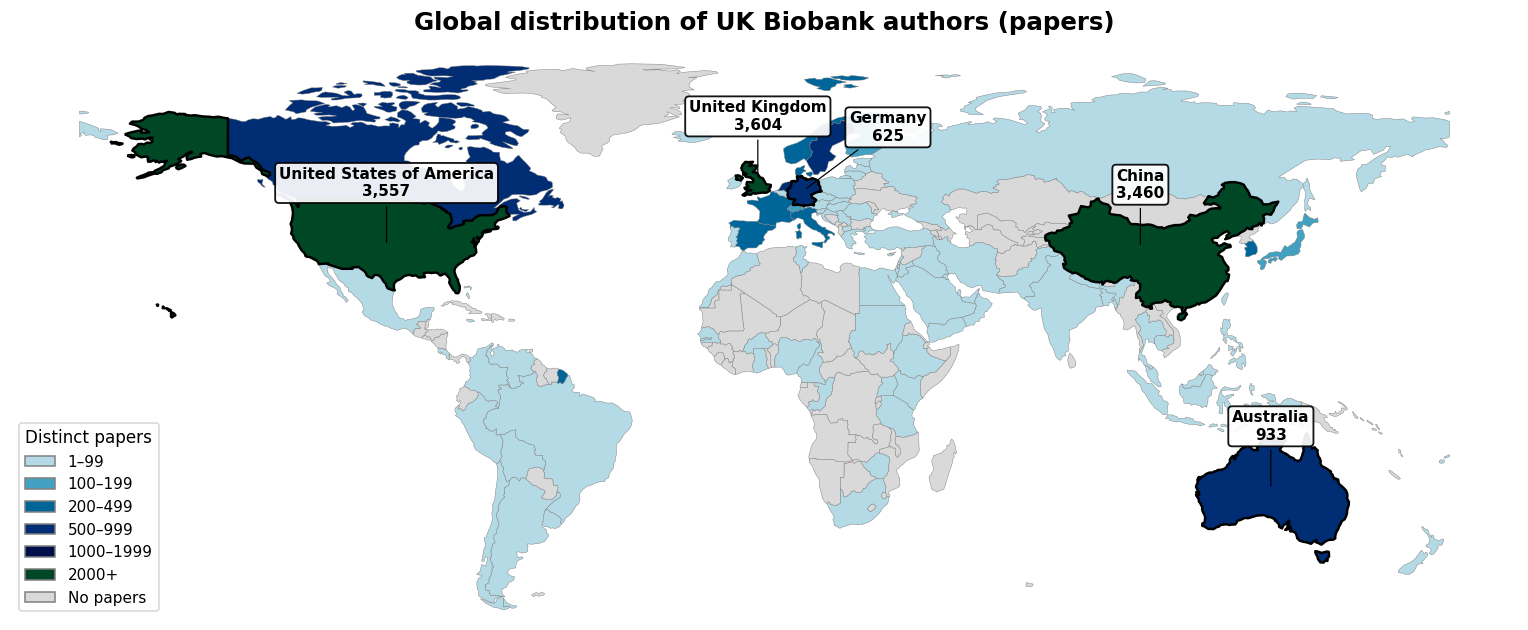

In [8]:
# Fixed bins for the papers choropleths (right-closed): 1-99, 100-199, 200-499,
# 500-999, 1000-1999, 2000+
PAPER_BINS = [0, 99, 199, 499, 999, 1999, np.inf]
PAPER_BIN_LABELS = ["1–99", "100–199", "200–499", "500–999", "1000–1999", "2000+"]


def plot_country_map(country_df, value_col="papers", style=STYLE, title=None, label=None,
                     name="geo_map", annotate_top=0, bins=None, bin_labels=None):
    """Choropleth world map of an author-geography metric.

    bins / bin_labels: if given, values are cut into those (right-closed) categorical
        classes, coloured as discrete samples of the shared `style['cmap']` (ocean_r:
        light = few papers, dark = many); countries with no data are grey.
    annotate_top: if >0, highlight+label that many highest-`value_col` countries
        (black outline + name + value, with leader lines / a greedy stagger).
    """
    from matplotlib.patches import Patch
    from matplotlib.colors import to_rgba

    GREY = "#D9D9D9"
    world = gpd.read_file("data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
    world.columns = [c.lower() for c in world.columns]
    world = world[world["admin"] != "Antarctica"]          # drop the south-polar row
    world["iso_key"] = world["iso_a3"].where(world["iso_a3"] != "-99", world["adm0_a3"])
    merged = world.merge(country_df, how="left", left_on="iso_key", right_on="iso3")

    fig, ax = plt.subplots(1, 1, figsize=style["figsize_map"])

    if bins is not None:
        labels = bin_labels or [f"{int(bins[i])+1}–{int(bins[i+1])}" for i in range(len(bins) - 1)]
        k = len(labels)
        cmap_obj = plt.get_cmap(style["cmap"])
        bin_cols = [cmap_obj(t) for t in np.linspace(0.90, 0.15, k)]  # few=light, many=dark
        cats = pd.cut(merged[value_col], bins=bins, labels=labels)
        codes = cats.cat.codes.to_numpy()
        grey_rgba = to_rgba(GREY)
        col_arr = np.array([bin_cols[c] if c >= 0 else grey_rgba for c in codes])
        merged.plot(color=col_arr, ax=ax, edgecolor=style["edgecolor"], linewidth=0.3)
        handles = [Patch(facecolor=bin_cols[i], edgecolor="grey", label=labels[i])
                   for i in range(k)]
        handles.append(Patch(facecolor=GREY, edgecolor="grey", label="No papers"))
        ax.legend(handles=handles, title=label or value_col, loc="lower left",
                  frameon=True, fontsize=style["legend_fs"] - 1,
                  title_fontsize=style["legend_fs"])
    else:
        merged.plot(column=value_col, ax=ax, legend=True, cmap=style["cmap"],
                    edgecolor=style["edgecolor"], linewidth=0.3,
                    missing_kwds={"color": GREY, "label": "No data"},
                    legend_kwds={"label": label or value_col, "shrink": 0.55})

    # ---- highlight + annotate the top-N countries (black) ----
    if annotate_top:
        top = merged.dropna(subset=[value_col]).nlargest(annotate_top, value_col)
        top.boundary.plot(ax=ax, edgecolor="black", linewidth=1.6)

        placed = []
        def free_slot(x, y):
            for dy in (16, -16, 30, -30, 44, -44, 58):
                for dx in (0, 22, -22, 42, -42):
                    cx, cy = x + dx, y + dy
                    if all(abs(cx - px) > 32 or abs(cy - py) > 12 for px, py in placed):
                        return cx, cy
            return x, y + 16

        for _, row in top.sort_values(value_col, ascending=False).iterrows():
            pt = row.geometry.representative_point()
            nm = row.get("name") or row.get("admin") or row["iso3"]
            lx, ly = free_slot(pt.x, pt.y)
            placed.append((lx, ly))
            ax.annotate(
                f"{nm}\n{int(row[value_col]):,}",
                xy=(pt.x, pt.y), xytext=(lx, ly), textcoords="data",
                ha="center", va="center", fontsize=style["annot_fs"],
                fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", lw=1.2, alpha=0.92),
                arrowprops=dict(arrowstyle="-", lw=0.8, color="black"),
                zorder=6,
            )

    ax.set_ylim(-58, 90)
    ax.set_title(title or f"Global distribution of UK Biobank authors ({value_col})",
                 fontsize=style["title_fs"], fontweight="bold")
    ax.axis("off")
    fig.tight_layout()
    savefig(fig, name, style)
    return fig, ax


fig, ax = plot_country_map(country_df, value_col="papers",
                           label="Distinct papers", name="geo_papers",
                           annotate_top=5, bins=PAPER_BINS, bin_labels=PAPER_BIN_LABELS)
plt.show()

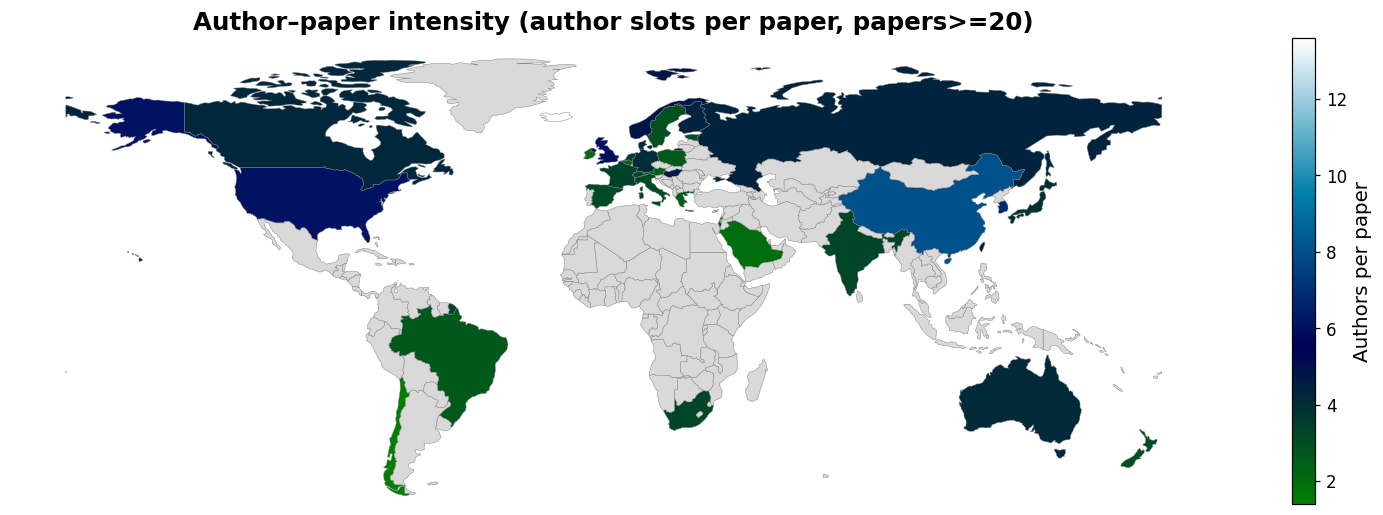

In [9]:
# Normalised view: collaboration intensity (authors per paper).
# Restrict to countries with a meaningful number of papers so the ratio is stable.
country_norm = country_df[country_df["papers"] >= 20]
fig, ax = plot_country_map(country_norm, value_col="authors_per_paper",
                           title="Author–paper intensity (author slots per paper, papers>=20)",
                           label="Authors per paper", name="geo_intensity")
plt.show()

### Cross-check with `geography.ipynb` (org-country basis)

`geography.ipynb` answers a slightly different question — *where are the research
**organisations**?* — using the paper-level `research_org_country_names` field, whereas
our `papers` column above counts *where the **authors** are affiliated*. The two will
**not** be identical:

* our author-affiliation basis is sensitive to Dimensions' **author-list truncation**
  and uses each author's **primary** affiliation only, so it runs **lower**;
* the org-country basis is paper-level and not truncated, so it matches `geography.ipynb`.

Below we reproduce the org-country basis here (`papers_org`) using the **same source
field** as `geography.ipynb` but our **robust ISO matcher** — which, unlike that
notebook's raw name→`ADMIN` join, does not silently drop Singapore (~191 papers),
Russia (~78), Serbia, Malta, etc. We show both side by side so the numbers reconcile
and the gap is transparent.

In [10]:
country_org = build_country_counts_orgbasis(df)
print("Countries represented (org-country basis):", len(country_org))

# Reconciliation table: author-affiliation vs org-country, distinct papers per country
recon = (country_df[["iso3", "country", "papers"]]
         .rename(columns={"papers": "papers_author_affil"})
         .merge(country_org[["iso3", "papers_org"]], on="iso3", how="outer"))
recon["country"] = recon["country"].fillna(
    recon["iso3"].map(country_org.set_index("iso3")["country"]))
recon = recon.sort_values("papers_org", ascending=False).reset_index(drop=True)
recon["author_vs_org_%"] = (100 * recon["papers_author_affil"]
                            / recon["papers_org"]).round(1)
print("\nTop 15 by org-country papers (author-affiliation vs org basis):")
recon.head(15)

Countries represented (org-country basis): 122

Top 15 by org-country papers (author-affiliation vs org basis):


,iso3,country,papers_author_affil,papers_org,author_vs_org_%
0,USA,United States,3557.0,4228.0,84.1
1,GBR,United Kingdom,3604.0,4205.0,85.7
2,CHN,China,3460.0,3666.0,94.4
3,AUS,Australia,933.0,1269.0,73.5
4,SWE,Sweden,592.0,955.0,62.0
5,DEU,Germany,625.0,944.0,66.2
6,NLD,Netherlands,588.0,942.0,62.4
7,CAN,Canada,533.0,722.0,73.8
8,DNK,Denmark,295.0,520.0,56.7
9,FRA,France,323.0,487.0,66.3


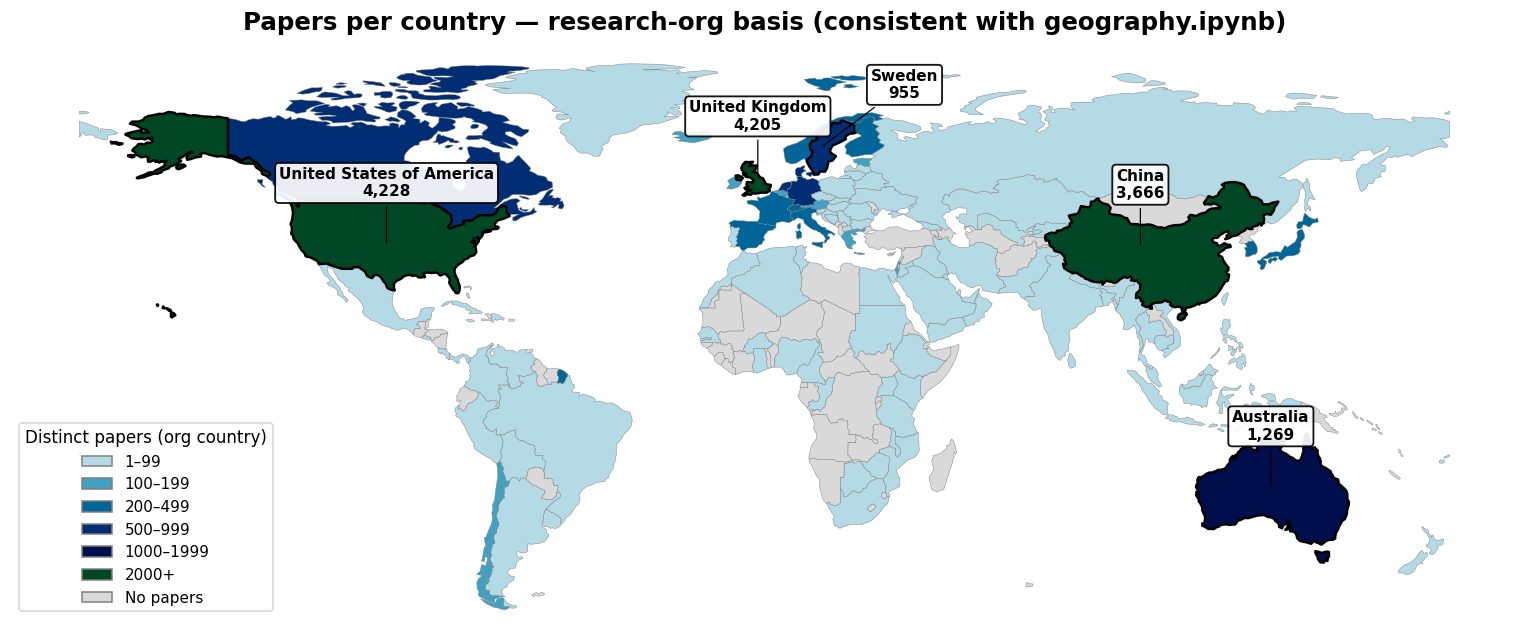

In [11]:
# Org-country choropleth — directly comparable to geography.ipynb's map,
# but matched via ISO-3 (Singapore, Russia, etc. are no longer dropped).
fig, ax = plot_country_map(country_org, value_col="papers_org",
                           title="Papers per country — research-org basis "
                                 "(consistent with geography.ipynb)",
                           label="Distinct papers (org country)", name="geo_papers_orgbasis",
                           annotate_top=5, bins=PAPER_BINS, bin_labels=PAPER_BIN_LABELS)
plt.show()

## 4. Top institutes

The most prolific institutions, using **fractional (author-level) counting**: each
author contributes **1 / (number of authors on their paper)** to their main-affiliation
institution. So a paper written across several universities gives each a *share* instead
of a full point, and an institution that supplied more of the author team earns
proportionally more credit — this avoids the whole-counting inflation where every
institution on a 50-author consortium paper would each score a full paper. (Pass
`counting="whole"` to `top_institutes` for the older distinct-papers measure.)

Each bar is still **stacked by Field of Research (FOR L2 division)** — each paper's
*primary* division carries its fractional weight — with the **top `n_for` divisions**
shown and the rest folded into *Other*. Colours come from the brand palette.

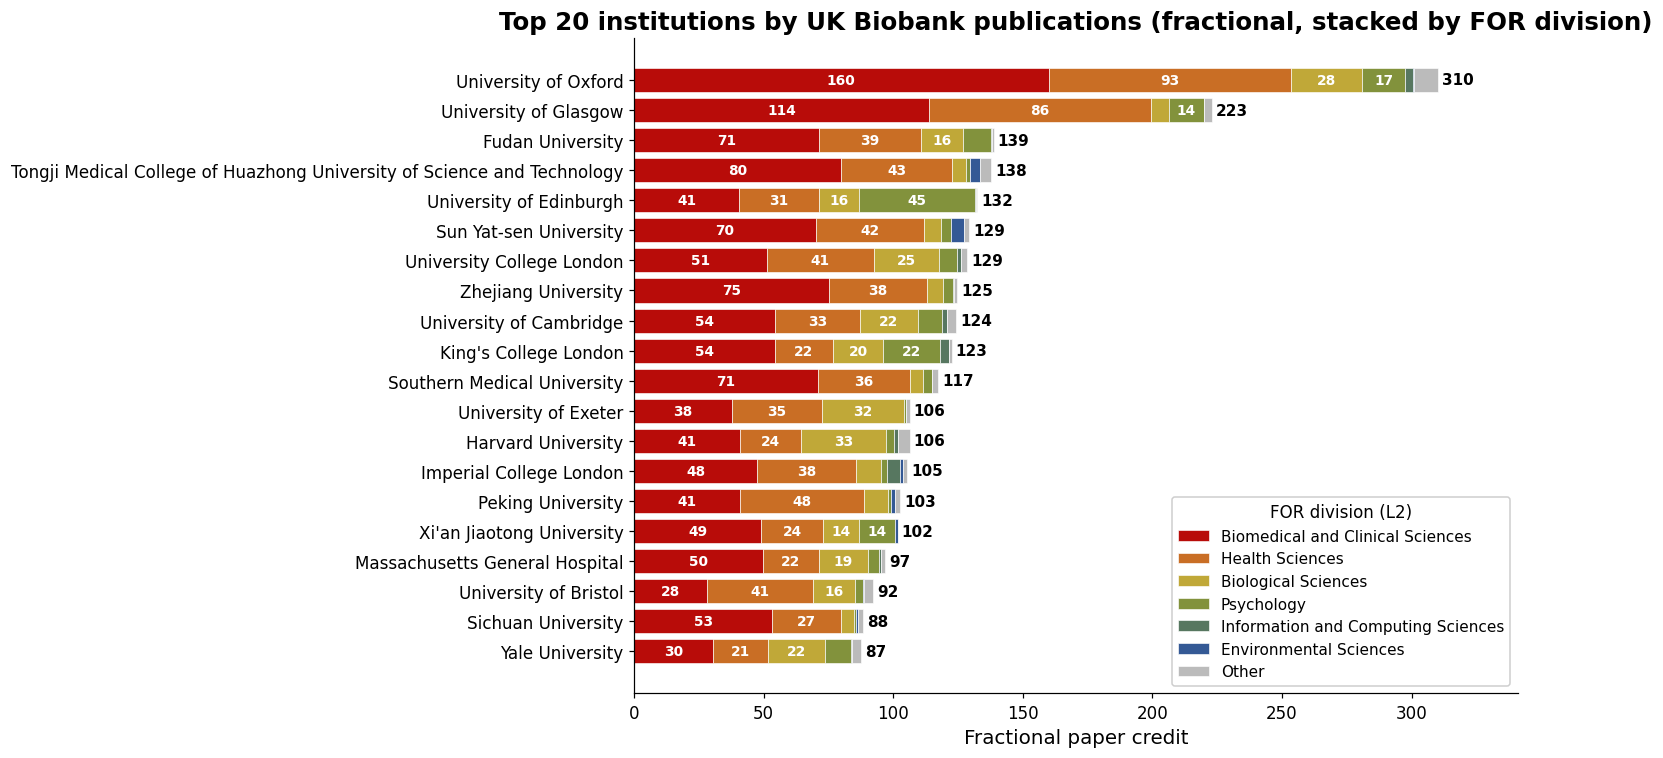

,org_name,papers,authors,country
0,University of Oxford,310.076969,734,United Kingdom
1,University of Glasgow,222.936110,256,United Kingdom
2,Fudan University,138.737971,399,China
3,Tongji Medical College of Huazhong University ...,137.851591,330,China
4,University of Edinburgh,132.334229,313,United Kingdom
5,Sun Yat-sen University,129.332230,482,China
6,University College London,128.634282,376,United Kingdom
7,Zhejiang University,124.617254,393,China
8,University of Cambridge,124.172333,368,United Kingdom
9,King's College London,122.577465,353,United Kingdom


In [ ]:
def top_institutes(ap, n=20, counting="fractional"):
    """Top-n institutions with a per-FOR-division breakdown.

    counting:
      'fractional' (default) — author-level fractional counting: each author
        contributes 1 / (number of authors on their paper) to their main-affiliation
        institution. A paper split across many universities therefore gives each a
        *share* rather than a full point, and an institution that supplied more of the
        team gets proportionally more credit. This is the standard fair-credit measure.
      'whole' — each paper counts 1 for every institution on it (distinct papers).
    """
    base = ap.dropna(subset=["org_name"]).copy()
    if counting == "fractional":
        authors_per_paper = ap.groupby("paper_id")["author_id"].transform("size")
        base["weight"] = 1.0 / authors_per_paper.loc[base.index]
        totals = (base.groupby("org_name")
                      .agg(papers=("weight", "sum"),
                           authors=("author_id", "nunique"),
                           country=("country", _mode))
                      .reset_index().sort_values("papers", ascending=False)
                      .head(n).reset_index(drop=True))
        breakdown = (base[base["org_name"].isin(totals["org_name"])]
                     .groupby(["org_name", "primary_for_l2"])["weight"].sum()
                     .reset_index(name="papers"))
    else:
        totals = (base.groupby("org_name")
                      .agg(papers=("paper_id", "nunique"),
                           authors=("author_id", "nunique"),
                           country=("country", _mode))
                      .reset_index().sort_values("papers", ascending=False)
                      .head(n).reset_index(drop=True))
        breakdown = (base[base["org_name"].isin(totals["org_name"])]
                     .groupby(["org_name", "primary_for_l2"])["paper_id"]
                     .nunique().reset_index(name="papers"))
    return totals, breakdown


def plot_top_institutes(totals, breakdown, n_for=6, style=STYLE,
                        name="top_institutes", value_label="Fractional paper credit"):
    order = totals.sort_values("papers")["org_name"].tolist()   # small->large (barh)

    top_divs = (breakdown.groupby("primary_for_l2")["papers"].sum()
                .sort_values(ascending=False).head(n_for).index.tolist())
    bk = breakdown.copy()
    bk["div"] = bk["primary_for_l2"].where(bk["primary_for_l2"].isin(top_divs), "Other")
    mat = (bk.groupby(["org_name", "div"])["papers"].sum()
             .unstack(fill_value=0).reindex(order))
    cols = [d for d in top_divs if d in mat.columns] + (["Other"] if "Other" in mat.columns else [])
    mat = mat[cols]

    pal = extended_palette(len(top_divs), style)
    cmap = {d: pal[i] for i, d in enumerate(top_divs)}
    cmap["Other"] = "#BBBBBB"

    fig, ax = plt.subplots(figsize=style["figsize_wide"])
    left = np.zeros(len(mat))
    seg_thresh = totals["papers"].max() * 0.04   # only label segments wide enough
    for d in cols:
        vals = mat[d].values
        ax.barh(mat.index, vals, left=left, color=cmap[d],
                edgecolor="white", linewidth=0.4, label=d)
        for y, (v, x0) in enumerate(zip(vals, left)):
            if v >= seg_thresh:
                ax.text(x0 + v / 2, y, f"{v:.1f}", va="center", ha="center",
                        fontsize=style["annot_fs"] - 1, color="white", fontweight="bold")
        left += vals
    totmap = totals.set_index("org_name")["papers"]
    for y, org in enumerate(mat.index):
        ax.text(totmap[org] + totmap.max() * 0.005, y, f"{totmap[org]:,.1f}",
                va="center", fontsize=style["annot_fs"], fontweight="bold")
    ax.set_xlabel(value_label)
    ax.set_title(f"Top {len(mat)} institutions by UK Biobank publications "
                 f"(fractional, stacked by FOR division)", fontsize=style["title_fs"],
                 fontweight="bold")
    ax.margins(x=0.10)
    ax.legend(title="FOR division (L2)", fontsize=style["legend_fs"] - 1,
              title_fontsize=style["legend_fs"], loc="lower right", framealpha=0.95)
    fig.tight_layout()
    savefig(fig, name, style)
    return fig, ax


inst_totals, inst_breakdown = top_institutes(df_ap, n=20, counting="fractional")
fig, ax = plot_top_institutes(inst_totals, inst_breakdown, n_for=6)
plt.show()
inst_totals

## 5. Gender trends over time

We infer author gender from first names with a **two-pass, fully offline** approach
(no network calls):

1. **`gender_guesser`** — a curated dictionary, strong on Western names.
2. **`nomquamgender`** (fallback for pass-1 `unknown`) — a much larger name→gender
   model built from ~100M+ tagged records. It gives each name a `P(female)` plus a
   support count; we accept a call only when the name has **≥ `min_counts`** observations
   and `P(female)` is **≥ `thr`** (female) or **≤ 1−`thr`** (male), leaving genuinely
   unisex names as `unknown`.

This matters here because **~43% of names were `unknown` after pass 1, and ~42% of those
are China-affiliated** (plus Korea/Taiwan/Singapore) — romanised East-Asian given names
that `gender_guesser` simply doesn't list. Pass 2 rescues a meaningful share of them
(e.g. *Xiaoyan*→F, *Jing*/*Hui*→F, *Wei*/*Ming*/*Yan*→M) while correctly abstaining on
truly ambiguous ones (*Zhuo*, *Lei*, *Hong*). The column `gender_source`
(`gender_guesser` / `nomquamgender` / `unknown`) records which pass decided each author.

Gender is assigned **once per author** (on their modal first name) and propagated to the
author–paper table, so each authorship inherits a gender. We then track the
**share of female authorships per year**.

> *Caveat:* even after refinement, many East-Asian names remain `unknown` because their
> romanised (pinyin) form is genuinely unisex — the character that carries the gender is
> lost. Treat the female-share **trend** as indicative, not its absolute level, and note
> that unknown coverage is uneven across countries.

In [13]:
_DET = gender_detector.Detector(case_sensitive=False)
_NQG = nqg.NBGC()   # loads the offline name-gender table once


def infer_gender(first_name):
    """Pass 1 — gender_guesser dictionary lookup on the first token of the name."""
    if not isinstance(first_name, str) or not first_name.strip():
        return "unknown"
    g = _DET.get_gender(first_name.strip().split()[0])
    if g in ("male", "mostly_male"):
        return "male"
    if g in ("female", "mostly_female"):
        return "female"
    return "unknown"


def assign_gender(first_names, thr=0.80, min_counts=30):
    """Two-pass gender per *unique* first name. Returns (gender_map, source_map).

    Pass 1: gender_guesser. Pass 2 (only for pass-1 'unknown'): nomquamgender, accepting
    a call when the name has >= min_counts support and P(female) >= thr / <= 1-thr.
    """
    uniq = [n for n in pd.unique(pd.Series(list(first_names)))
            if isinstance(n, str) and n.strip()]
    gender = {n: infer_gender(n) for n in uniq}
    source = {n: ("gender_guesser" if gender[n] != "unknown" else "unknown") for n in uniq}

    unknown = [n for n in uniq if gender[n] == "unknown"]
    if unknown:
        # columns: [name given, string used, #sources, #counts, p(female)]
        ann = _NQG.annotate(unknown, as_df=True).to_numpy()
        for nm, row in zip(unknown, ann):
            counts, p_gf = row[3], row[4]
            if counts >= min_counts and not pd.isna(p_gf):
                if p_gf >= thr:
                    gender[nm], source[nm] = "female", "nomquamgender"
                elif p_gf <= 1 - thr:
                    gender[nm], source[nm] = "male", "nomquamgender"
    return gender, source


# assign gender per author (two-pass), then propagate to the author-paper table
gender_map, source_map = assign_gender(df_authors["first_name"])
df_authors["gender"] = df_authors["first_name"].map(gender_map).fillna("unknown")
df_authors["gender_source"] = df_authors["first_name"].map(source_map).fillna("unknown")

df_ap = df_ap.drop(columns=[c for c in ("gender",) if c in df_ap.columns])
df_ap = df_ap.merge(df_authors[["author_id", "gender"]], on="author_id", how="left")

print("Gender distribution (authors):")
print(df_authors["gender"].value_counts(normalize=True).round(3).to_string())
print("\nDecided by (source):")
print(df_authors["gender_source"].value_counts().to_string())
rescued = int((df_authors["gender_source"] == "nomquamgender").sum())
unk_before = int((df_authors["first_name"].apply(infer_gender) == "unknown").sum())
print(f"\nPass-2 (nomquamgender) rescued {rescued:,} of {unk_before:,} pass-1 'unknown' "
      f"authors ({100*rescued/max(unk_before,1):.1f}%)")

Gender distribution (authors):
gender
male       0.386
unknown    0.337
female     0.277

Decided by (source):
gender_source
gender_guesser    22674
unknown           13414
nomquamgender      3680

Pass-2 (nomquamgender) rescued 3,680 of 17,094 pass-1 'unknown' authors (21.5%)


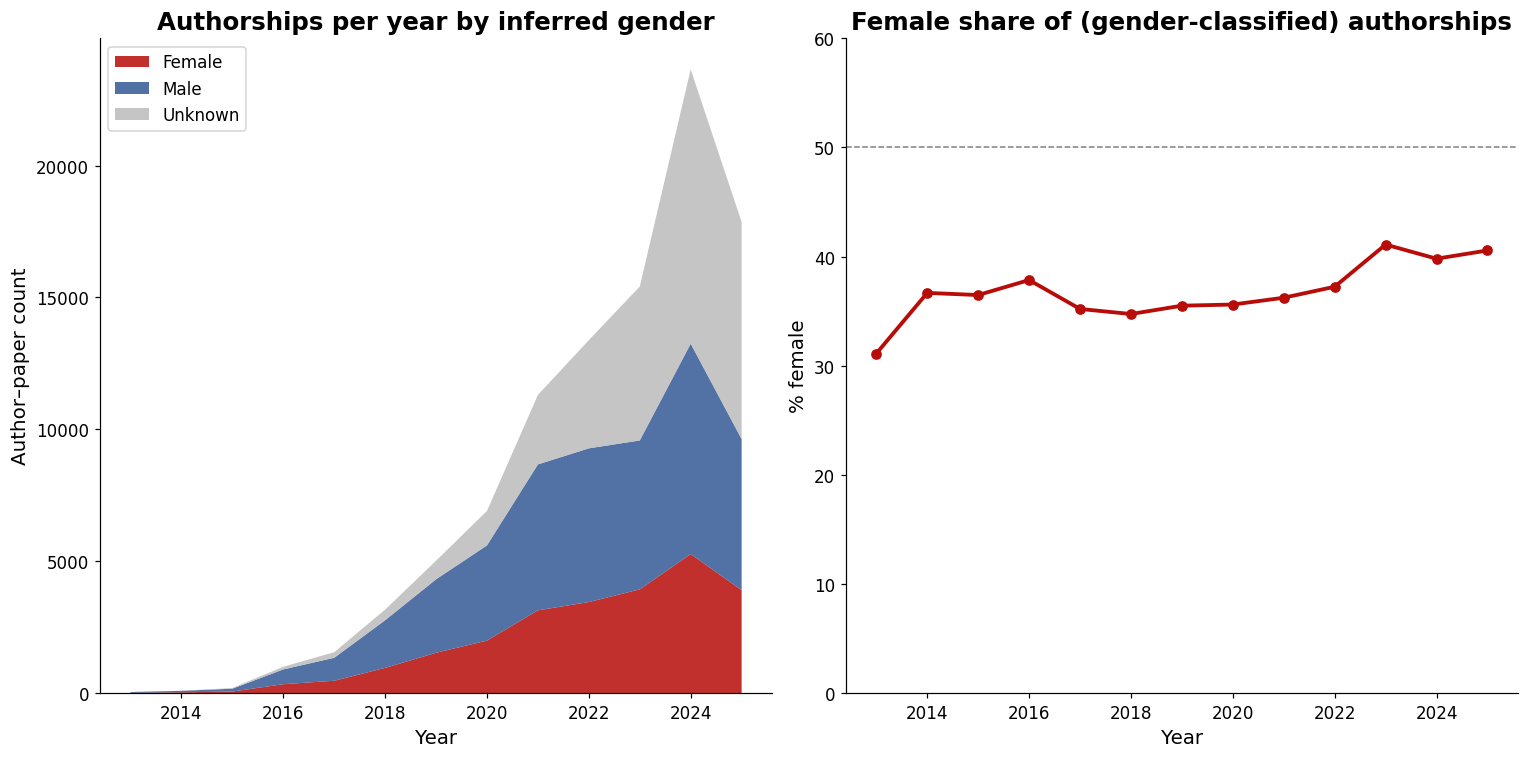

gender,female,male,unknown,female_share
year,,,,
2013,14,31,0,31.1
2014,33,57,2,36.7
2015,62,108,27,36.5
2016,341,560,102,37.8
2017,472,869,213,35.2
2018,960,1804,405,34.7
2019,1532,2784,704,35.5
2020,1994,3607,1308,35.6
2021,3141,5530,2635,36.2


In [14]:
def gender_over_time(ap, min_year=None, max_year=None):
    """Yearly authorship counts and female share among gender-classified authorships."""
    d = ap.dropna(subset=["year"]).copy()
    d["year"] = d["year"].astype(int)
    if min_year: d = d[d["year"] >= min_year]
    if max_year: d = d[d["year"] <= max_year]
    tab = d.pivot_table(index="year", columns="gender", values="paper_id",
                        aggfunc="count", fill_value=0)
    for c in ("female", "male", "unknown"):
        if c not in tab: tab[c] = 0
    tab["known"] = tab["female"] + tab["male"]
    tab["female_share"] = 100 * tab["female"] / tab["known"].replace(0, np.nan)
    return tab


def plot_gender_trends(tab, style=STYLE, name="gender_trends"):
    fig, axes = plt.subplots(1, 2, figsize=style["figsize_wide"])

    # (a) stacked authorship volume by gender
    ax = axes[0]
    ax.stackplot(tab.index, tab["female"], tab["male"], tab["unknown"],
                 labels=["Female", "Male", "Unknown"],
                 colors=[style["gender_colors"]["female"],
                         style["gender_colors"]["male"],
                         style["gender_colors"]["unknown"]], alpha=0.85)
    ax.set_title("Authorships per year by inferred gender",
                 fontsize=style["title_fs"], fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Author–paper count")
    ax.legend(loc="upper left")

    # (b) female share among classified authorships
    ax = axes[1]
    ax.plot(tab.index, tab["female_share"], marker="o",
            color=style["c_accent"], linewidth=2.5)
    ax.axhline(50, ls="--", color="grey", linewidth=1)
    ax.set_title("Female share of (gender-classified) authorships",
                 fontsize=style["title_fs"], fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("% female")
    ax.set_ylim(0, max(60, tab["female_share"].max() + 5))
    fig.tight_layout()
    savefig(fig, name, style)
    return fig, axes


gtab = gender_over_time(df_ap, min_year=2013)
fig, axes = plot_gender_trends(gtab)
plt.show()
gtab[["female", "male", "unknown", "female_share"]].round(1)

## 6. Network collaboration (final snapshot + growth panels)

A co-authorship network where nodes are authors and an edge links two authors who
appear on the same paper. Following
`01_analysis_02_network_over_time.ipynb`, we build a sparse bipartite
author×paper matrix `AP` and project it to the author–author network `AA = AP·APᵀ`.

We keep that notebook's **combined layout** for consistency — a single figure with the
**final cumulative snapshot (2025)** on the left and **four network-growth panels** on the
right (cumulative, year by year):

1. **Authors** — number of nodes,
2. **Collaborations** — number of edges,
3. **Avg collaborators / author** — mean degree,
4. **Giant-component size** — nodes in the largest component.

We do *not* produce the yearly GIF — just the final still. The full network (~40k
authors) is too large to lay out node-by-node, so metrics are computed on the **full
graph** while the drawn network is a **representative subgraph** (highest-degree authors
+ induced edges), coloured by component type using the shared palette.

In [15]:
from scipy.sparse.csgraph import connected_components

def build_coauthor_matrix(ap):
    """Sparse author-author co-authorship matrix AA = AP·APᵀ (edge weight = shared
    papers), plus the author-id array indexing its rows/cols. Pure scipy — building
    a 40k-node networkx graph is avoided; metrics come straight from the matrix."""
    authors = ap["author_id"].unique()
    papers = ap["paper_id"].unique()
    a2i = {a: i for i, a in enumerate(authors)}
    p2i = {p: i for i, p in enumerate(papers)}
    r = ap["author_id"].map(a2i).to_numpy()
    c = ap["paper_id"].map(p2i).to_numpy()
    AP = sp.csr_matrix((np.ones(len(r)), (r, c)), shape=(len(authors), len(papers)))
    AA = (AP @ AP.T).tocsr()
    AA.setdiag(0)
    AA.eliminate_zeros()                 # drop self-loops
    return AA, authors


def network_summary(AA):
    """Headline metrics computed directly from the sparse adjacency (fast)."""
    n = AA.shape[0]
    adj = AA > 0
    deg = np.asarray(adj.sum(axis=1)).ravel()
    n_edges = int(adj.nnz // 2)
    ncomp, labels = connected_components(adj, directed=False)
    giant = int(np.bincount(labels).max()) if n else 0
    return {
        "n_nodes": n,
        "n_edges": n_edges,
        "n_components": int(ncomp),
        "giant_nodes": giant,
        "giant_frac": giant / n if n else 0,
        "avg_degree": float(deg.mean()) if n else 0,
        "density": (2 * n_edges / (n * (n - 1)) if n > 1 else 0),
    }


def network_metrics_over_time(ap, min_year=None, max_year=None):
    """Cumulative co-authorship metrics, one row per year (for the side panels)."""
    d = ap.dropna(subset=["year"]).copy()
    d["year"] = d["year"].astype(int)
    y0 = int(min_year or d["year"].min())
    y1 = int(max_year or d["year"].max())
    recs = []
    for y in range(y0, y1 + 1):
        sub = d[d["year"] <= y]
        AA, _ = build_coauthor_matrix(sub)
        s = network_summary(AA)
        s["year"] = y
        s["n_papers"] = sub["paper_id"].nunique()
        recs.append(s)
    return pd.DataFrame(recs).set_index("year")


def render_subgraph(AA, authors, k=3000):
    """networkx graph of the k highest-degree authors (for drawing only)."""
    deg = np.asarray((AA > 0).sum(axis=1)).ravel()
    idx = np.argsort(deg)[::-1][:min(k, AA.shape[0])]
    H = nx.from_scipy_sparse_array(AA[idx][:, idx])
    return nx.relabel_nodes(H, {i: authors[idx[i]] for i in range(len(idx))})


# Full final network: matrix + headline metrics (sparse, ~1s)
AA, net_authors = build_coauthor_matrix(df_ap)
summary = network_summary(AA)
for k, v in summary.items():
    print(f"{k:>14}: {v:,.4f}" if isinstance(v, float) else f"{k:>14}: {v:,}")

# Subgraph to draw (top-degree authors) + cumulative metrics for the panels
RENDER_K = 3000
H_render = render_subgraph(AA, net_authors, k=RENDER_K)
metrics_ot = network_metrics_over_time(df_ap, min_year=2013)
metrics_ot[["n_nodes", "n_edges", "avg_degree", "giant_nodes"]]

       n_nodes: 39,768
       n_edges: 492,886
  n_components: 540
   giant_nodes: 35,614
    giant_frac: 0.8955
    avg_degree: 24.7881
       density: 0.0006


,n_nodes,n_edges,avg_degree,giant_nodes
year,,,,
2013,31,132,8.516129,14
2014,63,273,8.666667,19
2015,186,1399,15.043011,41
2016,702,8924,25.424501,553
2017,1545,26233,33.958576,1337
2018,3054,48167,31.543549,2757
2019,5110,82727,32.378474,4599
2020,8129,116356,28.627383,7154
2021,12513,178954,28.602893,11269


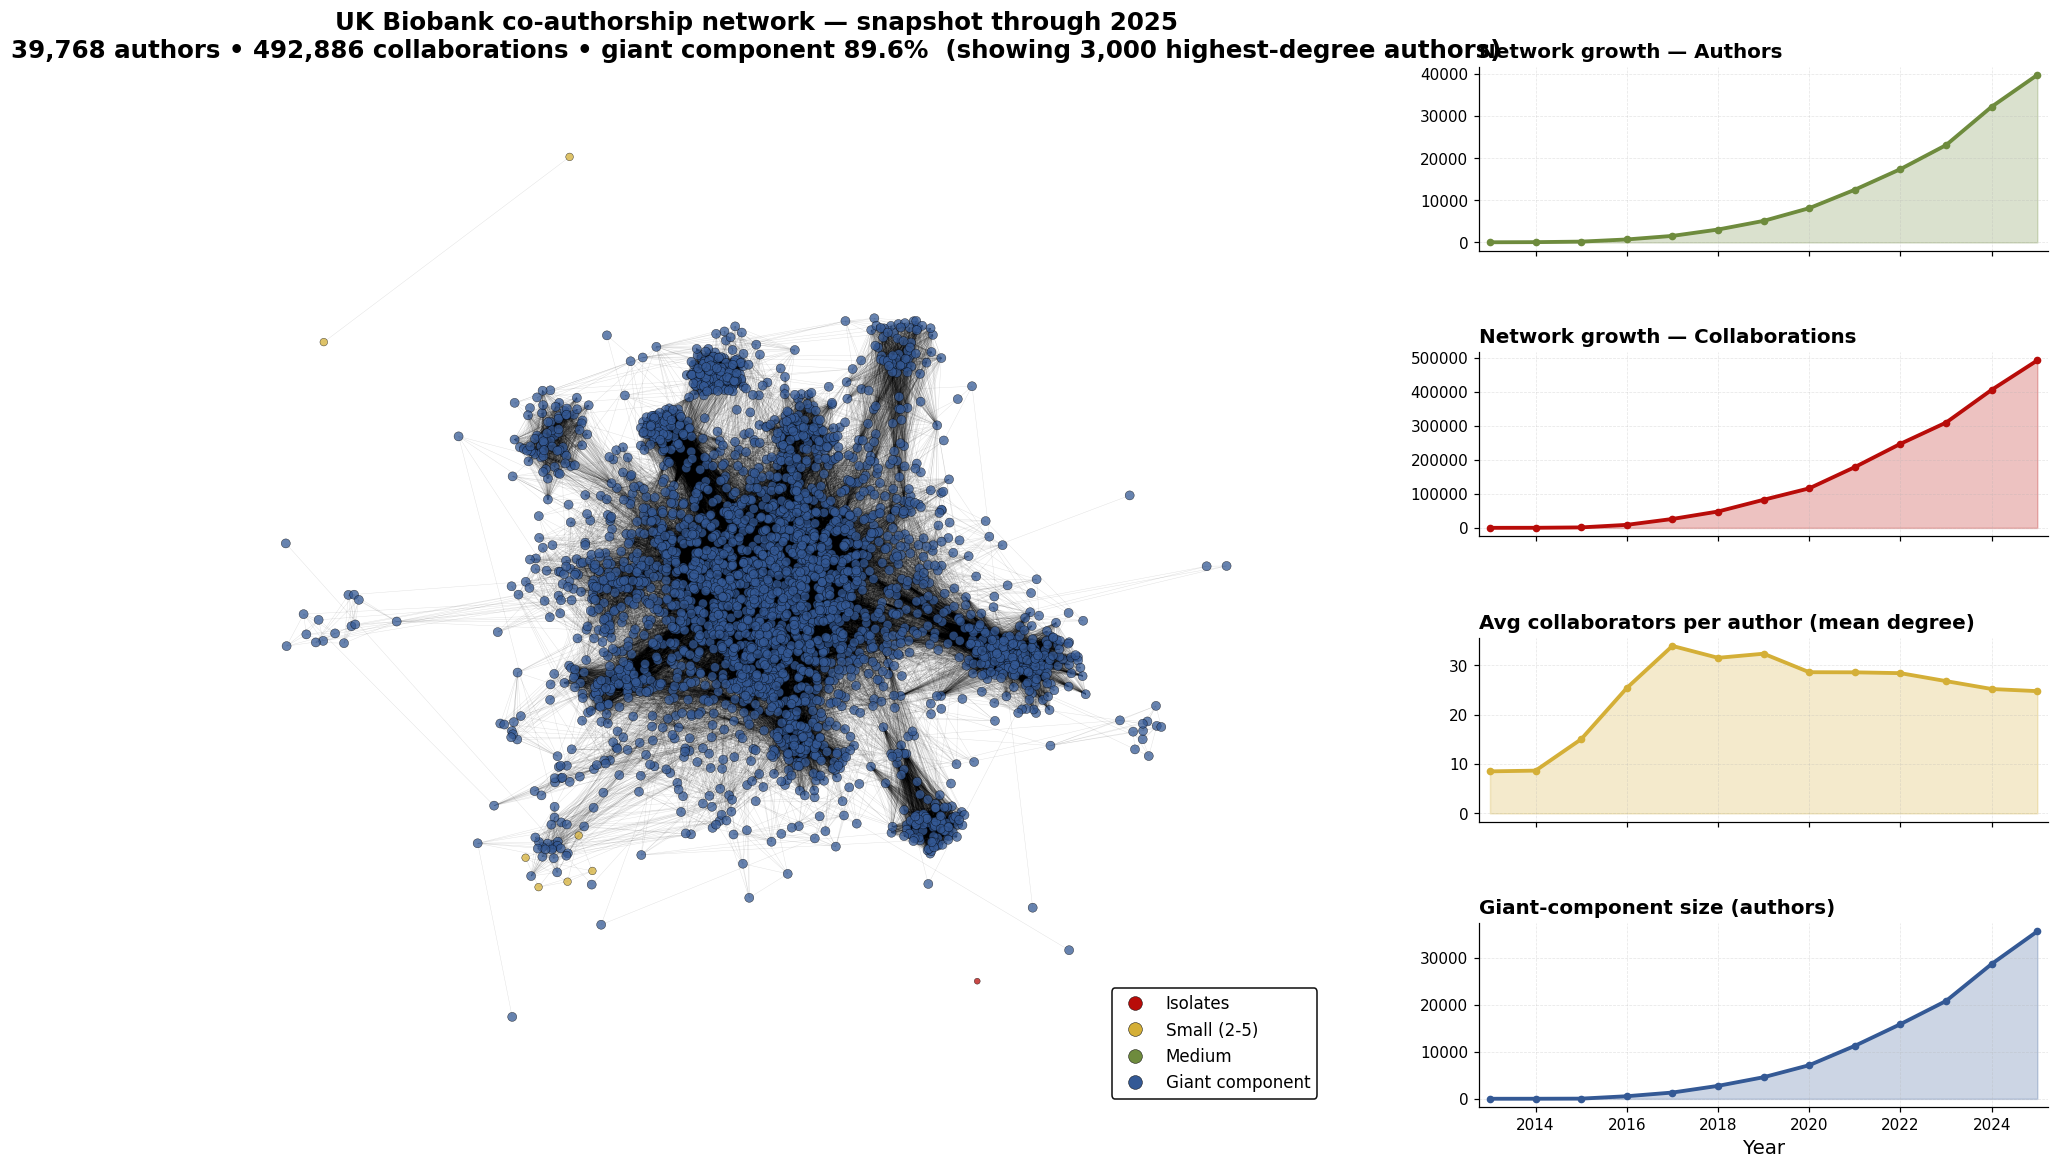

In [16]:
def _draw_network(ax, H, summary, style=STYLE, seed=48652):
    """Draw the (already-subsampled) render subgraph H onto `ax`; colour = component."""
    note = ("full network" if H.number_of_nodes() >= summary["n_nodes"]
            else f"showing {H.number_of_nodes():,} highest-degree authors")
    subset_note = note

    comps = sorted(nx.connected_components(H), key=len, reverse=True)
    node_comp = {n: (idx, len(comp)) for idx, comp in enumerate(comps) for n in comp}

    cols = style["colors"]
    node_colors, node_sizes = [], []
    for n in H.nodes():
        idx, size = node_comp[n]
        if size == 1:        node_colors.append(cols[0]); node_sizes.append(15)   # isolate
        elif size <= 5:      node_colors.append(cols[1]); node_sizes.append(25)   # small
        elif idx == 0:       node_colors.append(cols[3]); node_sizes.append(35)   # giant
        else:                node_colors.append(cols[2]); node_sizes.append(25)   # medium

    iters = 15 if H.number_of_nodes() > 1500 else 40
    pos = nx.spring_layout(H, k=0.3, iterations=iters, seed=seed)
    nx.draw_networkx_edges(H, pos, alpha=0.12, width=0.3, ax=ax)
    nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes,
                           alpha=0.75, edgecolors="k", linewidths=0.3, ax=ax)
    ax.axis("off")
    legend = [mlines.Line2D([], [], color=cols[i], marker="o", ls="None", markersize=9,
                            label=lab, markeredgecolor="k", markeredgewidth=0.3)
              for i, lab in [(0, "Isolates"), (1, "Small (2-5)"),
                             (2, "Medium"), (3, "Giant component")]]
    ax.legend(handles=legend, loc="lower right", frameon=True, framealpha=0.95,
              edgecolor="k", fontsize=style["legend_fs"])
    return subset_note


def plot_network_snapshot(H, summary, style=STYLE, seed=48652, name="network_snapshot"):
    """Standalone final-snapshot network (no side panels)."""
    fig, ax = plt.subplots(figsize=style["figsize_network"])
    note = _draw_network(ax, H, summary, style, seed)
    ax.set_title(
        f"UK Biobank co-authorship network — final snapshot\n"
        f"{summary['n_nodes']:,} authors • {summary['n_edges']:,} collaborations • "
        f"giant component {summary['giant_frac']*100:.1f}%  ({note})",
        fontsize=style["title_fs"], fontweight="bold")
    fig.tight_layout()
    savefig(fig, name, style)
    return fig, ax


def plot_network_with_panels(H, summary, metrics_ot, snapshot_year=2025,
                             style=STYLE, seed=48652, name="network_with_panels"):
    """Combined figure: final snapshot (left) + four cumulative growth panels (right).

    Mirrors the layout of 01_analysis_02_network_over_time.ipynb (network on the
    left, stacked metric panels on the right), but as a single still at `snapshot_year`.
    """
    fig = plt.figure(figsize=(18, 11))
    gs = fig.add_gridspec(4, 2, width_ratios=[2, 1], hspace=0.55, wspace=0.18,
                          left=0.03, right=0.97, top=0.92, bottom=0.06)

    # ---- left: network snapshot ----
    ax_net = fig.add_subplot(gs[:, 0])
    note = _draw_network(ax_net, H, summary, style, seed)
    ax_net.set_title(
        f"UK Biobank co-authorship network — snapshot through {snapshot_year}\n"
        f"{summary['n_nodes']:,} authors • {summary['n_edges']:,} collaborations • "
        f"giant component {summary['giant_frac']*100:.1f}%  ({note})",
        fontsize=style["title_fs"], fontweight="bold")

    # ---- right: four cumulative growth panels ----
    panels = [
        ("n_nodes",     "Network growth — Authors",                 style["c_green"]),
        ("n_edges",     "Network growth — Collaborations",          style["c_accent"]),
        ("avg_degree",  "Avg collaborators per author (mean degree)", style["c_gold"]),
        ("giant_nodes", "Giant-component size (authors)",           style["c_primary"]),
    ]
    x = metrics_ot.index
    for i, (col, title, c) in enumerate(panels):
        ax = fig.add_subplot(gs[i, 1])
        ax.plot(x, metrics_ot[col], color=c, linewidth=2.5, marker="o", markersize=4)
        ax.fill_between(x, 0, metrics_ot[col], color=c, alpha=0.25)
        ax.set_title(title, fontsize=style["label_fs"], fontweight="bold",
                     loc="left", pad=6)
        ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)
        ax.tick_params(labelsize=style["tick_fs"] - 1)
        ax.margins(x=0.02)
        if i < len(panels) - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("Year")
    savefig(fig, name, style)
    return fig


fig = plot_network_with_panels(H_render, summary, metrics_ot, snapshot_year=2025)
plt.show()

## Next step — modularisation

Once the analysis is settled, lift the function cells above into
`src/utils/author_utils.py` (one module, mirroring `utils/patent_utils.py`) and
replace them here with:

```python
from utils import author_utils as authors
```

The functions are already pure and `STYLE`-driven, so the move is mechanical:
`parse_listcol`, `pick_main_affiliation`, `build_author_paper_table`, `missing_report`,
`_split_for_name`, `build_for_lookup`,
`build_paper_for_table`, `build_grid_lookup`, `build_author_summary`, `to_iso3`,
`build_country_counts`,
`build_country_counts_orgbasis`, `plot_country_map`, `top_institutes`,
`plot_top_institutes`, `infer_gender`, `assign_gender`,
`gender_over_time`, `plot_gender_trends`, `build_coauthor_matrix`, `network_summary`,
`network_metrics_over_time`, `render_subgraph`, `_draw_network`,
`plot_network_snapshot`, `plot_network_with_panels` — plus `load_dimensions`, the
`STYLE` dict / `apply_style` / `extended_palette`.